# DINOv3 ViT-B Brain Tumor MRI Classification (Medically Defensible Augmentation)

## Research Question
> **How well does Medically Defensible Augmentation with fine-tuned DINOv3 ViT-B perform for 4-class brain tumor MRI classification, and how stable is the result across random seeds and cross-validation?**

## Methodological Rigor & Guardrails
1. **Medically Defensible Augmentation Only:** Employs anatomically and physically grounded transformations (horizontal flipping, mild rotation, subtle scale/translation, mild scanner-gain brightness/contrast). Strictly excludes destructive/unrealistic transforms such as vertical flipping (which destroys anterior/posterior polarity in axial MRI) and hue/saturation shifts (unrealistic for single-channel grayscale MR acquisitions).
2. **Strict Leakage Prevention:** Exact byte-level duplicates across train/test partitions are identified via SHA-256 hashing and decontaminated before model training. Test images are protected and train-side duplicates are removed.
3. **Fixed Validation Split:** A single stratified train/validation split (seed 42) is fixed across all experimental seeds to ensure strictly identical data partitions.
4. **Locked Model Selection:** Model checkpoints and the final champion seed are selected **strictly on validation macro-F1**. The test set is evaluated exactly once per seed after all model selection decisions are locked.
5. **Robustness & Uncertainty:** Evaluated across 3 independent random seeds (42, 123, 2026) and validated with 5-Fold Stratified Cross-Validation on the training pool.

## Section 1 — Setup, Authentication, and Configuration

This section installs required dependencies, authenticates with Hugging Face (required for gated DINOv3 access), and sets up global experiment hyperparameters.

In [ ]:
%pip install -q transformers huggingface_hub Pillow scipy scikit-learn matplotlib seaborn tqdm

In [ ]:
import os
import sys
import json
import copy
import time
import shutil
import random
import hashlib
import zipfile
from pathlib import Path
from datetime import datetime
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------------------------
# Global Configuration
# ---------------------------------------------------------------------------
CONFIG = {
    # Model Architecture
    "model_id": "facebook/dinov3-vitb16-pretrain-lvd1689m",
    "img_size": 224,
    "hidden_dim": 768,
    "n_unfreeze_blocks": 4,  # Fine-tune the last 4 transformer blocks
    "dropout": 0.3,

    # Data and Partitions
    "val_split": 0.15,
    "split_seed": 42,
    "seeds": [42, 123, 2026],
    "batch_size": 32,
    "num_workers": 2,

    # Optimization
    "epochs_finetune": 25,
    "patience": 7,
    "lr_head": 1e-3,
    "lr_backbone": 1e-5,
    "weight_decay": 1e-4,

    # Cross-Validation
    "cv_folds": 5,
    "cv_seed": 42,

    # Output directory
    "out_root": "results_dinov3_medically_defensible",
}

# Class mapping and standard display names
CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]
CLASS_DISPLAY = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASS_NAMES)}
IDX_TO_DISPLAY = {i: CLASS_DISPLAY[i] for i in range(len(CLASS_NAMES))}
NUM_CLASSES = len(CLASS_NAMES)

# Create output directories
OUT_ROOT = Path(CONFIG["out_root"])
CKPT_DIR = OUT_ROOT / "checkpoints"
FIG_DIR = OUT_ROOT / "figures"
METRICS_DIR = OUT_ROOT / "metrics"
for p in (OUT_ROOT, CKPT_DIR, FIG_DIR, METRICS_DIR):
    p.mkdir(parents=True, exist_ok=True)

# Save configuration
with open(OUT_ROOT / "experiment_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__} | Torchvision: {torchvision.__version__}")
print(f"Device:  {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"Output directory initialized at: {OUT_ROOT.resolve()}")

PyTorch: 2.11.0+cu128 | Torchvision: 0.26.0+cu128
Device:  cuda (NVIDIA A100-SXM4-40GB)
Output directory initialized at: /content/results_dinov3_medically_defensible


In [ ]:
# ---------------------------------------------------------------------------
# Hugging Face Authentication & Gated Access Verification
# ---------------------------------------------------------------------------
MANUAL_HF_TOKEN = ""  # Paste token here if not using Colab secrets or environment variable

if MANUAL_HF_TOKEN.strip():
    HF_TOKEN = MANUAL_HF_TOKEN.strip()
else:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        HF_TOKEN = os.environ.get("HF_TOKEN", None)

if HF_TOKEN:
    from huggingface_hub import login, HfApi
    login(token=HF_TOKEN, add_to_git_credential=False)
    try:
        api = HfApi()
        api.model_info(CONFIG["model_id"], token=HF_TOKEN)
        print(f"HuggingFace authentication successful. Access to '{CONFIG['model_id']}' confirmed.")
    except Exception as e:
        raise PermissionError(
            f"Authentication failed or model access not granted for '{CONFIG['model_id']}'. "
            "Please ensure you have accepted the model license terms at "
            f"https://huggingface.co/{CONFIG['model_id']} and your token has read permissions. Details: {e}"
        )
else:
    raise ValueError(
        f"HF_TOKEN is required to load gated DINOv3 weights ('{CONFIG['model_id']}'). "
        "Please provide HF_TOKEN via Colab Secrets, os.environ['HF_TOKEN'], or MANUAL_HF_TOKEN."
    )

HuggingFace authentication successful. Access to 'facebook/dinov3-vitb16-pretrain-lvd1689m' confirmed.


## Section 2 — Dataset Extraction and ZIP Integrity Verification

Calculates the SHA-256 hash of the dataset archive (`BT_Images.zip`), saves the hash to the experiment metadata for complete dataset reproducibility, and extracts a fresh working copy.

In [ ]:
# Locate or set dataset paths
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ZIP_PATH = "/content/drive/MyDrive/Data/BT_Images.zip"
    RAW_ROOT = "/content/BRISC_raw"
    CLEAN_ROOT = "/content/BRISC_cleaned_medically_defensible"
except Exception:
    ZIP_PATH = "./BT_Images.zip"
    RAW_ROOT = "./BRISC_raw"
    CLEAN_ROOT = "./BRISC_cleaned_medically_defensible"

def sha256_of_file(filepath, chunk_size=65536):
    h = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

# Compute and persist dataset ZIP SHA-256 hash if present
if os.path.exists(ZIP_PATH):
    zip_hash = sha256_of_file(ZIP_PATH)
    with open(OUT_ROOT / "zip_sha256.txt", "w") as f:
        f.write(f"{ZIP_PATH}: {zip_hash}\n")
    print(f"Dataset ZIP verified. SHA-256: {zip_hash}")
else:
    print(f"ZIP archive not found at {ZIP_PATH}. Checking existing directories...")

# Extract dataset if raw directory does not exist
TEMP_EXTRACT = "./_bt_extract_temp"
if not os.path.exists(RAW_ROOT) and os.path.exists(ZIP_PATH):
    print("Extracting dataset archive...")
    if os.path.exists(TEMP_EXTRACT):
        shutil.rmtree(TEMP_EXTRACT)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(TEMP_EXTRACT)

    # Resolve inner directory structure
    extracted_items = os.listdir(TEMP_EXTRACT)
    if len(extracted_items) == 1 and os.path.isdir(os.path.join(TEMP_EXTRACT, extracted_items[0])):
        src_base = os.path.join(TEMP_EXTRACT, extracted_items[0])
    else:
        src_base = TEMP_EXTRACT

    folder_map = {}
    for d in sorted(os.listdir(src_base)):
        dl = d.lower()
        full = os.path.join(src_base, d)
        if not os.path.isdir(full):
            continue
        if "train" in dl:
            folder_map["train"] = full
        elif "test" in dl:
            folder_map["test"] = full

    assert "train" in folder_map and "test" in folder_map, f"Could not detect train/test folders in {src_base}"

    os.makedirs(RAW_ROOT, exist_ok=True)
    shutil.copytree(folder_map["train"], os.path.join(RAW_ROOT, "train"))
    shutil.copytree(folder_map["test"], os.path.join(RAW_ROOT, "test"))
    shutil.rmtree(TEMP_EXTRACT)
    print(f"Raw dataset created at: {RAW_ROOT}")
elif os.path.exists(RAW_ROOT):
    print(f"Raw dataset already available at: {RAW_ROOT}")
else:
    raise FileNotFoundError(f"Neither {RAW_ROOT} nor {ZIP_PATH} found.")

# Prepare fresh working copy for decontamination
if os.path.exists(CLEAN_ROOT):
    shutil.rmtree(CLEAN_ROOT)
shutil.copytree(RAW_ROOT, CLEAN_ROOT)
print(f"Clean working copy created at: {CLEAN_ROOT}")

Mounted at /content/drive
Dataset ZIP verified. SHA-256: 0ceb678ffe75819bf7bf59a67d6dbf05aae5b1feb5b57201feee513af4bb8e5c
Extracting dataset archive...
Raw dataset created at: /content/BRISC_raw
Clean working copy created at: /content/BRISC_cleaned_medically_defensible


## Section 3 — Exact Duplicate Audit and Decontamination

We hash every image across train and test partitions using SHA-256. We perform:
1. **Label Conflict Audit:** Check if identical image hashes carry contradictory ground-truth labels.
2. **Cross-Split Decontamination:** Protect the holdout test set by removing all train-side copies of test images.
3. **Within-Split Deduplication:** Keep exactly one unique copy per distinct image within each split.

> [!NOTE]
> Exact duplicate decontamination completed. Note: SHA-256 decontaminates exact byte-level image duplicates across partitions; patient-level leakage cannot be fully verified if patient/study IDs are unavailable in the source dataset.

In [ ]:
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def normalize_class_name(dir_name: str) -> str:
    name = dir_name.lower().strip()
    if "glioma" in name:
        return "glioma"
    elif "meningioma" in name:
        return "meningioma"
    elif "pituitary" in name:
        return "pituitary"
    elif "no" in name:  # Handles 'no_tumor', 'notumor', 'no'
        return "no_tumor"
    raise ValueError(f"Unrecognized class directory name: '{dir_name}'")

def list_images(split_dir):
    rows = []
    for class_dir in sorted(Path(split_dir).iterdir()):
        if not class_dir.is_dir():
            continue
        cls = normalize_class_name(class_dir.name)
        for fp in sorted(class_dir.iterdir()):
            if fp.suffix.lower() in VALID_EXT:
                rows.append((str(fp), cls))
    return rows

train_raw_rows = list_images(os.path.join(CLEAN_ROOT, "train"))
test_raw_rows = list_images(os.path.join(CLEAN_ROOT, "test"))
print(f"Raw images indexed: train={len(train_raw_rows)}, test={len(test_raw_rows)}")

# Compute SHA-256 for all images
hash_to_entries = defaultdict(list)
for fp, cls in tqdm(train_raw_rows, desc="Hashing train"):
    hash_to_entries[sha256_of_file(fp)].append({"path": fp, "split": "train", "class": cls})
for fp, cls in tqdm(test_raw_rows, desc="Hashing test"):
    hash_to_entries[sha256_of_file(fp)].append({"path": fp, "split": "test", "class": cls})

# 1. Label Conflict Check
conflicts = []
duplicate_groups = {h: entries for h, entries in hash_to_entries.items() if len(entries) > 1}
for h, entries in duplicate_groups.items():
    labels = {e["class"] for e in entries}
    if len(labels) > 1:
        conflicts.append({"hash": h, "classes": list(labels), "entries": entries})

if conflicts:
    print(f"WARNING: Found {len(conflicts)} duplicate groups with conflicting labels!")
    for c in conflicts[:5]:
        print(f"  Hash {c['hash'][:12]} has conflicting labels: {c['classes']}")
else:
    print("Exact duplicate label conflict check: PASSED (zero conflicting labels across identical images).")

# 2. Cross-Split & Within-Split Decontamination
to_remove = set()
cross_split_count = 0
for h, entries in duplicate_groups.items():
    train_entries = [e for e in entries if e["split"] == "train"]
    test_entries = [e for e in entries if e["split"] == "test"]

    if train_entries and test_entries:
        # Cross-split duplicate: Protect test set, remove ALL train copies
        cross_split_count += 1
        for e in train_entries:
            to_remove.add(e["path"])
        # Also deduplicate within test if multiple copies exist
        for e in test_entries[1:]:
            to_remove.add(e["path"])
    else:
        # Within-split duplicate: Keep exactly one copy
        for e in entries[1:]:
            to_remove.add(e["path"])

print(f"Cross-split duplicate groups (train <-> test): {cross_split_count}")
print(f"Total duplicate files removed: {len(to_remove)}")

for fp in to_remove:
    Path(fp).unlink()

# Build cleaned lists
clean_train_rows = [(fp, cls) for fp, cls in train_raw_rows if fp not in to_remove]
clean_test_rows = [(fp, cls) for fp, cls in test_raw_rows if fp not in to_remove]

clean_train_fps = [fp for fp, _ in clean_train_rows]
clean_train_labels = [cls for _, cls in clean_train_rows]
clean_train_labels_int = [CLASS_TO_IDX[c] for c in clean_train_labels]

clean_test_fps = [fp for fp, _ in clean_test_rows]
clean_test_labels = [cls for _, cls in clean_test_rows]
clean_test_labels_int = [CLASS_TO_IDX[c] for c in clean_test_labels]

# Hard assertion for cross-split decontamination
train_hashes_post = {sha256_of_file(fp) for fp in clean_train_fps}
test_hashes_post = {sha256_of_file(fp) for fp in clean_test_fps}
assert len(train_hashes_post & test_hashes_post) == 0, "LEAKAGE: Byte-identical images remain shared between train and test!"

audit_summary = {
    "raw_train_count": len(train_raw_rows),
    "raw_test_count": len(test_raw_rows),
    "duplicate_groups_total": len(duplicate_groups),
    "conflicting_label_groups": len(conflicts),
    "cross_split_groups": cross_split_count,
    "total_removed_files": len(to_remove),
    "clean_train_count": len(clean_train_fps),
    "clean_test_count": len(clean_test_fps),
    "leakage_audit_passed": True,
    "patient_level_note": "Exact duplicate decontamination completed. SHA256 verified zero cross-split exact duplicates. Patient-level clustering cannot be verified in the absence of patient IDs."
}
with open(METRICS_DIR / "exact_duplicate_audit.json", "w") as f:
    json.dump(audit_summary, f, indent=2)

print("Exact duplicate decontamination completed successfully.")
print(f"surviving train pool: {len(clean_train_fps)} | surviving holdout test: {len(clean_test_fps)}")

Raw images indexed: train=5000, test=1000


Hashing train:   0%|          | 0/5000 [00:00<?, ?it/s]

Hashing test:   0%|          | 0/1000 [00:00<?, ?it/s]

Exact duplicate label conflict check: PASSED (zero conflicting labels across identical images).
Cross-split duplicate groups (train <-> test): 7
Total duplicate files removed: 50
Exact duplicate decontamination completed successfully.
surviving train pool: 4955 | surviving holdout test: 995


## Section 4 — Fixed Stratified Train and Validation Split

We construct a single stratified train/validation split from the training pool using `CONFIG["split_seed"]` (42). This exact partition is frozen and used for all multi-seed training experiments to ensure strictly identical training conditions.

In [ ]:
idx_train, idx_val = train_test_split(
    list(range(len(clean_train_fps))),
    test_size=CONFIG["val_split"],
    stratify=clean_train_labels_int,
    random_state=CONFIG["split_seed"],
)

train_fps = [clean_train_fps[i] for i in idx_train]
train_labs = [clean_train_labels_int[i] for i in idx_train]

val_fps = [clean_train_fps[i] for i in idx_val]
val_labs = [clean_train_labels_int[i] for i in idx_val]

test_fps = clean_test_fps
test_labs = clean_test_labels_int

# Verify partition integrity
assert len(set(train_fps) & set(val_fps)) == 0, "Overlap between train and val paths!"
assert len(set(train_fps) & set(test_fps)) == 0, "Overlap between train and test paths!"
assert len(set(val_fps) & set(test_fps)) == 0, "Overlap between val and test paths!"

# Compute and display class distributions
def get_class_counts(label_indices):
    c = Counter(label_indices)
    return {IDX_TO_DISPLAY[i]: c.get(i, 0) for i in range(NUM_CLASSES)}

dist_df = pd.DataFrame([
    {"Split": "Train (Fixed)", **get_class_counts(train_labs), "Total": len(train_fps)},
    {"Split": "Val (Fixed)", **get_class_counts(val_labs), "Total": len(val_fps)},
    {"Split": "Test (Holdout)", **get_class_counts(test_labs), "Total": len(test_fps)},
])

dist_df.to_csv(METRICS_DIR / "class_distributions.csv", index=False)
print("=" * 70)
print("DATASET PARTITION DISTRIBUTIONS (STRATIFIED)")
print("=" * 70)
print(dist_df.to_string(index=False))
print("=" * 70)

DATASET PARTITION DISTRIBUTIONS (STRATIFIED)
         Split  Glioma  Meningioma  No Tumor  Pituitary  Total
 Train (Fixed)     975        1113       899       1224   4211
   Val (Fixed)     172         197       159        216    744
Test (Holdout)     253         303       139        300    995


## Section 5 — Medically Defensible Augmentation Strategy

### Clinical and Anatomical Justification for MRI Transforms
Augmentation for brain MRI must preserve anatomical plausibility and diagnostic fidelity:
- **Random Horizontal Flip ($p=0.5$):** Medically valid. Brain anatomy displays bilateral axial symmetry; mirroring horizontally simulates naturally occurring hemispheric presentations without altering pathological characteristics.
- **Small Random Rotation ($\pm 10^\circ$):** Medically valid. Models slight patient head tilt inside the scanner head coil.
- **Subtle Affine Translation ($\pm 5\%$) & Scaling ($0.95 - 1.05$):** Medically valid. Simulates small patient shifts from scanner isocenter and standard voxel FOV variations.
- **Mild Brightness & Contrast Jitter ($0.15$):** Medically valid. Simulates B0/B1 field inhomogeneities, coil sensitivity profile differences, and varying pulse sequence gain across different MRI scanners.
- **EXCLUDED — Vertical Flip:** Unrealistic. Axial MRI scans have strict anterior-to-posterior orientation; vertically inverting the brain produces unphysical anatomical configurations.
- **EXCLUDED — Hue / Saturation Jitter:** Unrealistic. Brain MRI is natively a single-channel grayscale intensity-weighted modality (T1, T2, FLAIR); altering hue/saturation creates synthetic chromatic artifacts foreign to clinical neuro-radiology.
- **EXCLUDED — Aggressive RandAugment / Heavy Erasing:** Prevents erasing small focal lesions (e.g., micro-adenomas or focal meningiomas) or simulating synthetic signal voids.

In [ ]:
# ---------------------------------------------------------------------------
# Medically Defensible Augmentation & Deterministic Preprocessing
# ---------------------------------------------------------------------------
DINO_MEAN = [0.485, 0.456, 0.406]
DINO_STD = [0.229, 0.224, 0.225]

# 1. Medically Defensible Training Transform
transform_medically_defensible = T.Compose([
    T.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=DINO_MEAN, std=DINO_STD),
])

# 2. Deterministic Preprocessing for Validation and Test
transform_deterministic = T.Compose([
    T.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    T.ToTensor(),
    T.Normalize(mean=DINO_MEAN, std=DINO_STD),
])

class ImageListDataset(Dataset):
    """Dataset loading images from path lists with explicit RGB conversion."""
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

print("Medically Defensible Augmentation pipeline defined.")

Medically Defensible Augmentation pipeline defined.


## Section 6 — DINOv3 Model Setup and Architecture Inspection

Constructs the `DINOv3Classifier` with an MLP classification head on the `[CLS]` token. Unfreezes the last $N$ transformer blocks (`CONFIG["n_unfreeze_blocks"] = 4`) and displays a comprehensive breakdown of trainable vs. frozen parameters.

In [ ]:
from transformers import AutoModel

class MLPHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class DINOv3Classifier(nn.Module):
    def __init__(self, backbone, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.head = MLPHead(hidden_dim, 256, num_classes, dropout)

    def forward(self, x):
        out = self.backbone(x)
        # Use [CLS] token representation
        cls_token = out.last_hidden_state[:, 0]
        return self.head(cls_token)


def get_transformer_layers(backbone):
    """Finds the sequence of transformer blocks in various Hugging Face ViT / DINOv3 architectures."""
    candidates = [
        lambda m: m.encoder.layer,
        lambda m: m.encoder.layers,
        lambda m: m.layers,
        lambda m: m.model.encoder.layer,
        lambda m: m.model.layers,
    ]
    for getter in candidates:
        try:
            blocks = getter(backbone)
            if isinstance(blocks, (nn.ModuleList, list, tuple)) and len(blocks) > 0:
                return blocks
        except (AttributeError, TypeError):
            continue
    return None


def unfreeze_last_n_blocks(model, n_blocks: int):
    """Freezes the entire backbone, then unfreezes only the last n_blocks and the head."""
    # Freeze all backbone parameters
    for param in model.backbone.parameters():
        param.requires_grad = False

    unfrozen_block_names = []
    blocks = get_transformer_layers(model.backbone)

    if blocks is not None:
        total_blocks = len(blocks)
        unfreeze_start = max(0, total_blocks - n_blocks)
        for i in range(unfreeze_start, total_blocks):
            for param in blocks[i].parameters():
                param.requires_grad = True
            unfrozen_block_names.append(f"encoder.layer.{i}")
    else:
        # Fallback: parse parameter names containing numeric block indices
        block_params = defaultdict(list)
        for name, param in model.backbone.named_parameters():
            for part in name.split("."):
                if part.isdigit():
                    block_params[int(part)].append((name, param))
                    break
        if block_params:
            max_block = max(block_params.keys())
            for block_idx in range(max_block - n_blocks + 1, max_block + 1):
                for name, param in block_params.get(block_idx, []):
                    param.requires_grad = True
                unfrozen_block_names.append(f"block_{block_idx}")

    # Head parameters are always trainable
    for param in model.head.parameters():
        param.requires_grad = True

    return unfrozen_block_names


def print_parameter_inspection(model, unfrozen_names):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    head_p = sum(p.numel() for p in model.head.parameters() if p.requires_grad)
    pct = (trainable / total) * 100.0

    print("=" * 70)
    print("DINOv3 ViT-B ARCHITECTURE INSPECTION")
    print("=" * 70)
    print(f"Total Parameters:            {total:,}")
    print(f"Trainable Parameters:        {trainable:,} ({pct:.2f}%)")
    print(f"Frozen Parameters:           {total - trainable:,} ({100 - pct:.2f}%)")
    print(f"Classification Head Params:  {head_p:,}")
    print(f"Unfrozen Transformer Blocks: {len(unfrozen_names)} blocks")
    for name in unfrozen_names:
        print(f"  - {name}")
    print("=" * 70)

# Instantiate and inspect model structure
sample_backbone = AutoModel.from_pretrained(CONFIG["model_id"], token=HF_TOKEN).to(device)
sample_model = DINOv3Classifier(sample_backbone, CONFIG["hidden_dim"], NUM_CLASSES, CONFIG["dropout"]).to(device)
unfrozen_blocks = unfreeze_last_n_blocks(sample_model, CONFIG["n_unfreeze_blocks"])
print_parameter_inspection(sample_model, unfrozen_blocks)
del sample_model, sample_backbone
torch.cuda.empty_cache()

config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  343MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

DINOv3 ViT-B ARCHITECTURE INSPECTION
Total Parameters:            85,858,308
Trainable Parameters:        28,552,452 (33.26%)
Frozen Parameters:           57,305,856 (66.74%)
Classification Head Params:  197,892
Unfrozen Transformer Blocks: 4 blocks
  - block_8
  - block_9
  - block_10
  - block_11


## Section 7 — Training and Evaluation Utilities

Implements the training loop with:
1. **Validation Macro-F1 Checkpoint Selection:** Best checkpoint is saved when validation Macro-F1 improves (with validation loss as secondary tie-breaker).
2. **Strict Encapsulation:** Evaluation accepts validation or test loaders independently. Test set is strictly locked during training.

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def compute_metrics(y_true, y_pred):
    """Computes all multiclass classification metrics (values stored in [0.0, 1.0])."""
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "kappa": float(cohen_kappa_score(y_true, y_pred)),
    }


@torch.no_grad()
def evaluate_dataset(model, loader, device):
    """Runs inference and computes predictions, probabilities, true labels, and metrics."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy() if isinstance(lbls, torch.Tensor) else lbls)
        all_probs.append(probs)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.concatenate(all_probs, axis=0)
    metrics = compute_metrics(all_labels, all_preds)
    return all_preds, all_probs, all_labels, metrics


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    epochs,
    patience,
    device,
    desc="Training",
):
    """Training loop with validation Macro-F1 checkpoint selection."""
    best_val_f1 = -1.0
    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "val_macro_f1": [],
        "lr": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, n_samples = 0.0, 0
        train_preds, train_trues = [], []

        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            n_samples += imgs.size(0)
            train_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            train_trues.extend(lbls.cpu().numpy())

        train_loss = running_loss / n_samples
        train_acc = float(accuracy_score(train_trues, train_preds))

        # Validation Phase
        model.eval()
        val_running_loss, val_n = 0.0, 0
        val_preds, val_trues = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                val_running_loss += loss.item() * imgs.size(0)
                val_n += imgs.size(0)
                val_preds.extend(outputs.argmax(dim=1).cpu().numpy())
                val_trues.extend(lbls.cpu().numpy())

        val_loss = val_running_loss / val_n
        val_acc = float(accuracy_score(val_trues, val_preds))
        val_f1 = float(f1_score(val_trues, val_preds, average="macro", zero_division=0))
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_f1)
        history["lr"].append(current_lr)

        if scheduler is not None:
            scheduler.step(val_loss)

        # Primary selection: Validation Macro-F1 | Tie-breaker: Validation Loss
        improved = False
        if val_f1 > best_val_f1 + 1e-5:
            improved = True
        elif abs(val_f1 - best_val_f1) <= 1e-5 and val_loss < best_val_loss:
            improved = True

        if improved:
            best_val_f1 = val_f1
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            tag = "*BEST*"
        else:
            patience_counter += 1
            tag = f"(patience {patience_counter}/{patience})"

        if epoch % 5 == 0 or epoch == 1 or improved:
            print(f"  [{desc}] Epoch {epoch:02d}/{epochs:02d} | "
                  f"TrainLoss={train_loss:.4f} Acc={train_acc*100:.2f}% | "
                  f"ValLoss={val_loss:.4f} Acc={val_acc*100:.2f}% Macro-F1={val_f1*100:.2f}% {tag}")

        if patience_counter >= patience:
            print(f"  [{desc}] Early stopping triggered at epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_f1, best_val_loss, best_epoch

print("Training and evaluation utilities defined.")

Training and evaluation utilities defined.


## Section 8 — Multi-Seed Training (Seeds 42, 123, 2026)

Trains the DINOv3 ViT-B model using Medically Defensible Augmentation across 3 independent random seeds (`42`, `123`, `2026`). All seeds share the exact same fixed stratified train/validation split.

In [ ]:
criterion = nn.CrossEntropyLoss()

# Storage structures per seed
val_results_by_seed = []
histories_by_seed = {}
checkpoint_paths_by_seed = {}

# Deterministic fixed validation loader
val_dataset = ImageListDataset(val_fps, val_labs, transform=transform_deterministic)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

for seed in CONFIG["seeds"]:
    print(f"\n{'='*70}\nTRAINING | Medically Defensible Augmentation | Seed={seed}\n{'='*70}")
    set_seed(seed)

    # Data loader with seed worker init
    g = torch.Generator()
    g.manual_seed(seed)
    train_dataset = ImageListDataset(train_fps, train_labs, transform=transform_medically_defensible)
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=CONFIG["num_workers"],
        worker_init_fn=seed_worker,
        generator=g,
        pin_memory=True,
    )

    # Build model
    backbone = AutoModel.from_pretrained(CONFIG["model_id"], token=HF_TOKEN).to(device)
    model = DINOv3Classifier(backbone, CONFIG["hidden_dim"], NUM_CLASSES, CONFIG["dropout"]).to(device)
    unfreeze_last_n_blocks(model, CONFIG["n_unfreeze_blocks"])

    # Two-tier optimizer
    backbone_params = [p for n, p in model.named_parameters() if "head" not in n and p.requires_grad]
    head_params = list(model.head.parameters())
    optimizer = optim.Adam([
        {"params": backbone_params, "lr": CONFIG["lr_backbone"]},
        {"params": head_params, "lr": CONFIG["lr_head"]},
    ], weight_decay=CONFIG["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    model, history, best_val_f1, best_val_loss, best_epoch = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        scheduler,
        criterion,
        CONFIG["epochs_finetune"],
        CONFIG["patience"],
        device,
        desc=f"Seed-{seed}",
    )

    # Save checkpoint
    ckpt_path = CKPT_DIR / f"dinov3_med_defensible_seed{seed}.pth"
    torch.save(model.state_dict(), ckpt_path)
    checkpoint_paths_by_seed[seed] = str(ckpt_path)
    histories_by_seed[seed] = history

    # Final evaluation on validation set
    _, _, _, val_metrics = evaluate_dataset(model, val_loader, device)
    val_results_by_seed.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_macro_precision": val_metrics["macro_precision"],
        "val_macro_recall": val_metrics["macro_recall"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "val_loss": best_val_loss,
        "checkpoint_path": str(ckpt_path),
    })

    del model, backbone, train_loader
    torch.cuda.empty_cache()

# Persist validation results and histories
df_val_results = pd.DataFrame(val_results_by_seed)
df_val_results.to_csv(METRICS_DIR / "validation_results_by_seed.csv", index=False)
with open(METRICS_DIR / "training_histories.json", "w") as f:
    json.dump(histories_by_seed, f, indent=2)

print("\n" + "=" * 70)
print("VALIDATION RESULTS BY SEED (PRIMARY SELECTION PHASE)")
print("=" * 70)
val_disp = df_val_results.copy()
for col in ["val_accuracy", "val_balanced_accuracy", "val_macro_f1", "val_weighted_f1"]:
    val_disp[col] = val_disp[col].apply(lambda x: f"{x*100:.2f}%")
print(val_disp[["seed", "best_epoch", "val_accuracy", "val_balanced_accuracy", "val_macro_f1", "val_loss"]].to_string(index=False))
print("=" * 70)


TRAINING | Medically Defensible Augmentation | Seed=42


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  [Seed-42] Epoch 01/25 | TrainLoss=0.3936 Acc=85.40% | ValLoss=0.1705 Acc=93.95% Macro-F1=94.08% *BEST*
  [Seed-42] Epoch 02/25 | TrainLoss=0.1246 Acc=95.56% | ValLoss=0.1246 Acc=95.43% Macro-F1=95.45% *BEST*
  [Seed-42] Epoch 03/25 | TrainLoss=0.0789 Acc=97.15% | ValLoss=0.1031 Acc=96.24% Macro-F1=96.31% *BEST*
  [Seed-42] Epoch 04/25 | TrainLoss=0.0538 Acc=98.03% | ValLoss=0.0862 Acc=97.31% Macro-F1=97.31% *BEST*
  [Seed-42] Epoch 05/25 | TrainLoss=0.0397 Acc=98.58% | ValLoss=0.0882 Acc=97.04% Macro-F1=97.04% (patience 1/7)
  [Seed-42] Epoch 06/25 | TrainLoss=0.0377 Acc=98.55% | ValLoss=0.0839 Acc=97.45% Macro-F1=97.47% *BEST*
  [Seed-42] Epoch 07/25 | TrainLoss=0.0256 Acc=99.17% | ValLoss=0.0849 Acc=97.58% Macro-F1=97.64% *BEST*
  [Seed-42] Epoch 10/25 | TrainLoss=0.0144 Acc=99.53% | ValLoss=0.1047 Acc=97.98% Macro-F1=97.97% *BEST*
  [Seed-42] Epoch 12/25 | TrainLoss=0.0186 Acc=99.26% | ValLoss=0.0757 Acc=98.12% Macro-F1=98.10% *BEST*
  [Seed-42] Epoch 13/25 | TrainLoss=0.0123 Acc=

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  [Seed-123] Epoch 01/25 | TrainLoss=0.3693 Acc=85.66% | ValLoss=0.1546 Acc=94.09% Macro-F1=94.18% *BEST*
  [Seed-123] Epoch 02/25 | TrainLoss=0.1300 Acc=95.42% | ValLoss=0.1197 Acc=95.70% Macro-F1=95.70% *BEST*
  [Seed-123] Epoch 04/25 | TrainLoss=0.0618 Acc=97.82% | ValLoss=0.1235 Acc=96.24% Macro-F1=96.18% *BEST*
  [Seed-123] Epoch 05/25 | TrainLoss=0.0439 Acc=98.46% | ValLoss=0.0627 Acc=97.85% Macro-F1=97.87% *BEST*
  [Seed-123] Epoch 06/25 | TrainLoss=0.0305 Acc=99.03% | ValLoss=0.0701 Acc=97.98% Macro-F1=98.00% *BEST*
  [Seed-123] Epoch 09/25 | TrainLoss=0.0257 Acc=99.00% | ValLoss=0.0797 Acc=98.12% Macro-F1=98.15% *BEST*
  [Seed-123] Epoch 10/25 | TrainLoss=0.0152 Acc=99.48% | ValLoss=0.0693 Acc=97.98% Macro-F1=97.99% (patience 1/7)
  [Seed-123] Epoch 11/25 | TrainLoss=0.0080 Acc=99.79% | ValLoss=0.0644 Acc=98.66% Macro-F1=98.65% *BEST*
  [Seed-123] Epoch 14/25 | TrainLoss=0.0112 Acc=99.48% | ValLoss=0.0649 Acc=98.79% Macro-F1=98.80% *BEST*
  [Seed-123] Epoch 15/25 | TrainLoss=0

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  [Seed-2026] Epoch 01/25 | TrainLoss=0.3947 Acc=84.42% | ValLoss=0.1726 Acc=94.35% Macro-F1=94.59% *BEST*
  [Seed-2026] Epoch 03/25 | TrainLoss=0.0806 Acc=97.25% | ValLoss=0.1052 Acc=95.83% Macro-F1=95.93% *BEST*
  [Seed-2026] Epoch 05/25 | TrainLoss=0.0526 Acc=98.05% | ValLoss=0.0703 Acc=97.72% Macro-F1=97.74% *BEST*
  [Seed-2026] Epoch 07/25 | TrainLoss=0.0294 Acc=98.98% | ValLoss=0.0736 Acc=97.72% Macro-F1=97.75% *BEST*
  [Seed-2026] Epoch 09/25 | TrainLoss=0.0239 Acc=99.24% | ValLoss=0.0603 Acc=98.39% Macro-F1=98.39% *BEST*
  [Seed-2026] Epoch 10/25 | TrainLoss=0.0112 Acc=99.67% | ValLoss=0.0699 Acc=98.25% Macro-F1=98.27% (patience 1/7)
  [Seed-2026] Epoch 11/25 | TrainLoss=0.0140 Acc=99.53% | ValLoss=0.0763 Acc=98.79% Macro-F1=98.81% *BEST*
  [Seed-2026] Epoch 15/25 | TrainLoss=0.0068 Acc=99.74% | ValLoss=0.0723 Acc=98.66% Macro-F1=98.67% (patience 4/7)
  [Seed-2026] Early stopping triggered at epoch 18.

VALIDATION RESULTS BY SEED (PRIMARY SELECTION PHASE)
 seed  best_epoch val_

## Section 9 — Final Checkpoint Selection (Validation Macro-F1 Only)

The champion model seed is selected **exclusively on validation Macro-F1** (with validation loss as secondary tie-breaker). The test set remains completely unaccessed.

In [ ]:
# Sort strictly by validation Macro-F1 (descending), then validation loss (ascending)
best_row = df_val_results.sort_values(
    by=["val_macro_f1", "val_loss"],
    ascending=[False, True]
).iloc[0]

FINAL_SEED = int(best_row["seed"])
FINAL_CHECKPOINT = Path(best_row["checkpoint_path"])
FINAL_BEST_EPOCH = int(best_row["best_epoch"])

# Copy champion checkpoint to root
FINAL_SAVED_MODEL = OUT_ROOT / "dinov3_medically_defensible_final.pth"
shutil.copyfile(FINAL_CHECKPOINT, FINAL_SAVED_MODEL)

final_selection_info = {
    "selection_rule": "Highest validation Macro-F1 across 3 training seeds on fixed validation split (test set unaccessed).",
    "final_seed": FINAL_SEED,
    "final_checkpoint_source": str(FINAL_CHECKPOINT),
    "final_checkpoint_saved": str(FINAL_SAVED_MODEL),
    "best_validation_macro_f1": float(best_row["val_macro_f1"]),
    "best_validation_accuracy": float(best_row["val_accuracy"]),
    "best_validation_loss": float(best_row["val_loss"]),
    "best_epoch": FINAL_BEST_EPOCH,
}

with open(METRICS_DIR / "final_model_selection.json", "w") as f:
    json.dump(final_selection_info, f, indent=2)

print("=" * 70)
print(f"FINAL MODEL SELECTED: Seed {FINAL_SEED}")
print("=" * 70)
print(f"Selected Epoch:          {FINAL_BEST_EPOCH}")
print(f"Validation Macro-F1:     {best_row['val_macro_f1']*100:.2f}%")
print(f"Validation Accuracy:     {best_row['val_accuracy']*100:.2f}%")
print(f"Validation Loss:         {best_row['val_loss']:.4f}")
print(f"Champion Checkpoint:     {FINAL_SAVED_MODEL}")
print("Selection locked. Proceeding to confirmatory test evaluation.")

FINAL MODEL SELECTED: Seed 42
Selected Epoch:          15
Validation Macro-F1:     99.07%
Validation Accuracy:     99.06%
Validation Loss:         0.0543
Champion Checkpoint:     results_dinov3_medically_defensible/dinov3_medically_defensible_final.pth
Selection locked. Proceeding to confirmatory test evaluation.


## Section 10 — Locked Holdout Test Evaluation

Now that all model selection decisions are locked, we evaluate each seed's checkpoint on the protected holdout test set. We report the mean and standard deviation across all 3 seeds.

> [!IMPORTANT]
> Test results report mean and standard deviation across 3 random seeds on the holdout test set. As patient/study IDs are unavailable in this dataset, these statistics reflect image-level variation rather than patient-level clustered uncertainty.

In [ ]:
# Test DataLoader (Deterministic preprocessing)
test_dataset = ImageListDataset(test_fps, test_labs, transform=transform_deterministic)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

predictions_by_seed = {}
probabilities_by_seed = {}
labels_by_seed = {}
test_metrics_by_seed = []

for seed in CONFIG["seeds"]:
    ckpt_path = checkpoint_paths_by_seed[seed]

    backbone = AutoModel.from_pretrained(CONFIG["model_id"], token=HF_TOKEN).to(device)
    model = DINOv3Classifier(backbone, CONFIG["hidden_dim"], NUM_CLASSES, CONFIG["dropout"]).to(device)
    unfreeze_last_n_blocks(model, CONFIG["n_unfreeze_blocks"])
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.to(device)

    preds, probs, labs, metrics = evaluate_dataset(model, test_loader, device)
    predictions_by_seed[seed] = preds
    probabilities_by_seed[seed] = probs
    labels_by_seed[seed] = labs

    test_metrics_by_seed.append({
        "seed": seed,
        "is_final_selected_seed": (seed == FINAL_SEED),
        **metrics,
    })

    del model, backbone
    torch.cuda.empty_cache()

df_test_results = pd.DataFrame(test_metrics_by_seed)
df_test_results.to_csv(METRICS_DIR / "test_results_by_seed.csv", index=False)

# Calculate aggregate statistics (Mean and Std across 3 seeds)
metric_fields = ["accuracy", "balanced_accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1", "kappa"]
summary_rows = []
for m in metric_fields:
    vals = df_test_results[m].values
    summary_rows.append({
        "metric": m,
        "mean": float(vals.mean()),
        "std": float(vals.std(ddof=1)),
        "formatted": f"{vals.mean()*100:.2f}% ± {vals.std(ddof=1)*100:.2f}%",
    })
df_test_summary = pd.DataFrame(summary_rows)
df_test_summary.to_csv(METRICS_DIR / "test_summary_statistics.csv", index=False)

print("=" * 70)
print("LOCKED TEST SET EVALUATION SUMMARY (3 SEEDS)")
print("=" * 70)
print(df_test_summary[["metric", "formatted"]].to_string(index=False))
print("=" * 70)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

LOCKED TEST SET EVALUATION SUMMARY (3 SEEDS)
           metric      formatted
         accuracy 98.83% ± 0.21%
balanced_accuracy 98.95% ± 0.18%
  macro_precision 98.98% ± 0.20%
     macro_recall 98.95% ± 0.18%
         macro_f1 98.97% ± 0.18%
      weighted_f1 98.83% ± 0.21%
            kappa 98.40% ± 0.29%


## Section 11 — Per-Class Classification Results (Final Model)

Extracts and tabulates precision, recall, F1-score, and support for each of the 4 diagnostic classes using predictions from the champion model (`FINAL_SEED`).

In [ ]:
final_preds = predictions_by_seed[FINAL_SEED]
final_labels = labels_by_seed[FINAL_SEED]
final_probs = probabilities_by_seed[FINAL_SEED]

report_dict = classification_report(
    final_labels,
    final_preds,
    target_names=CLASS_DISPLAY,
    output_dict=True,
    zero_division=0,
)

per_class_rows = []
for cls_name in CLASS_DISPLAY:
    r = report_dict[cls_name]
    per_class_rows.append({
        "Class": cls_name,
        "Precision": float(r["precision"]),
        "Recall": float(r["recall"]),
        "F1-Score": float(r["f1-score"]),
        "Support": int(r["support"]),
    })

df_per_class = pd.DataFrame(per_class_rows)
df_per_class.to_csv(METRICS_DIR / "per_class_test_metrics.csv", index=False)

print("=" * 70)
print(f"PER-CLASS TEST PERFORMANCE (FINAL MODEL: SEED {FINAL_SEED})")
print("=" * 70)
disp_class = df_per_class.copy()
for col in ["Precision", "Recall", "F1-Score"]:
    disp_class[col] = disp_class[col].apply(lambda x: f"{x*100:.2f}%")
print(disp_class.to_string(index=False))
print("=" * 70)

PER-CLASS TEST PERFORMANCE (FINAL MODEL: SEED 42)
     Class Precision  Recall F1-Score  Support
    Glioma    98.81%  98.42%   98.61%      253
Meningioma    98.03%  98.68%   98.36%      303
  No Tumor   100.00% 100.00%  100.00%      139
 Pituitary    99.67%  99.33%   99.50%      300


## Section 12 — Confusion Matrix (Final Model)

Plots the multi-class confusion matrix on the test set for the champion model (`FINAL_SEED`).

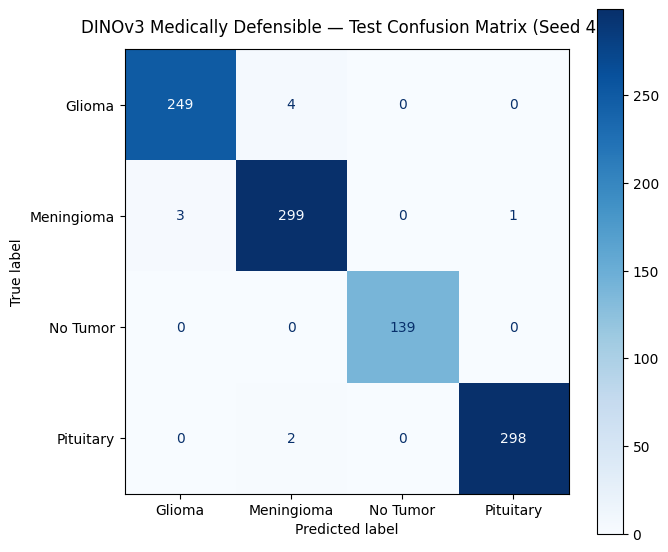

Confusion matrix figure saved to: results_dinov3_medically_defensible/figures/confusion_matrix_final_model.png


In [ ]:
cm = confusion_matrix(final_labels, final_preds)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_DISPLAY)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', colorbar=True)

plt.title(f"DINOv3 Medically Defensible — Test Confusion Matrix (Seed {FINAL_SEED})", fontsize=12, pad=12)
plt.grid(False)
plt.tight_layout()

cm_path = FIG_DIR / "confusion_matrix_final_model.png"
plt.savefig(cm_path, dpi=300)
plt.show()
print(f"Confusion matrix figure saved to: {cm_path}")

## Section 13 — Receiver Operating Characteristic (ROC) and AUC

Generates One-vs-Rest (OvR) ROC curves and computes area-under-the-curve (AUC) for each class on the holdout test set using the champion model (`FINAL_SEED`).

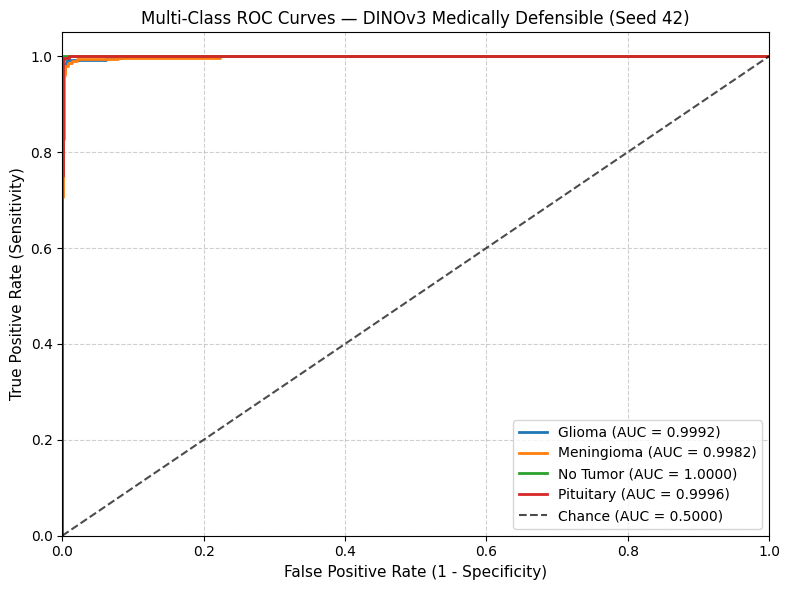

ROC curves figure saved to: results_dinov3_medically_defensible/figures/roc_curve_final_model.png


In [ ]:
y_test_bin = label_binarize(final_labels, classes=[0, 1, 2, 3])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], final_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
plt.figure(figsize=(8, 6))
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"{CLASS_DISPLAY[i]} (AUC = {roc_auc[i]:.4f})",
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7, label="Chance (AUC = 0.5000)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=11)
plt.title(f"Multi-Class ROC Curves — DINOv3 Medically Defensible (Seed {FINAL_SEED})", fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

roc_path = FIG_DIR / "roc_curve_final_model.png"
plt.savefig(roc_path, dpi=300)
plt.show()
print(f"ROC curves figure saved to: {roc_path}")

## Section 14 — Training and Validation Curves (Final Model)

Plots the loss and accuracy curves directly from the stored training history of the champion model (`FINAL_SEED`) without retraining.

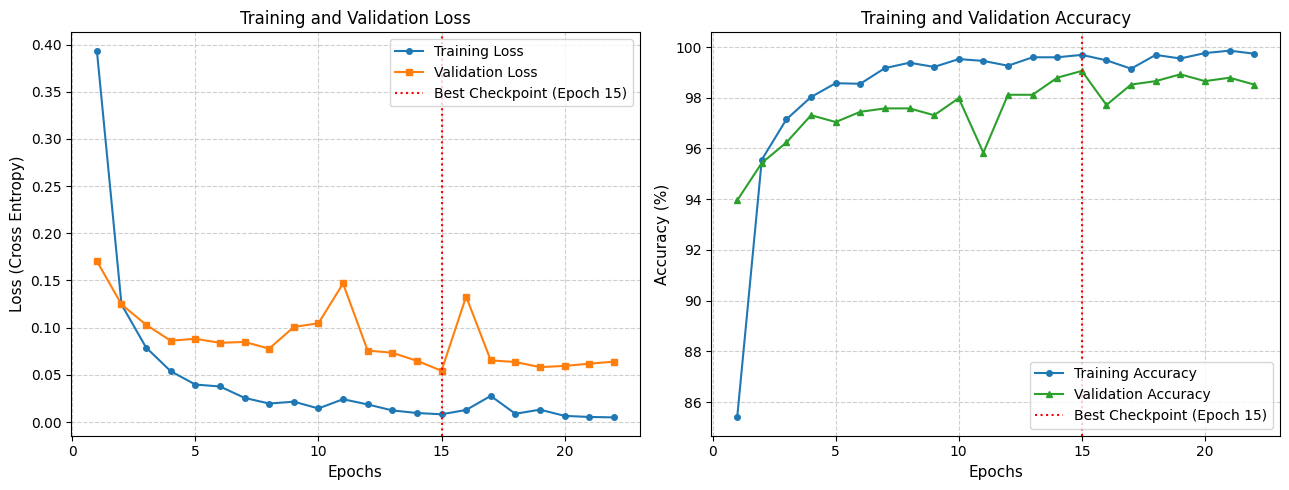

Training curves saved to: results_dinov3_medically_defensible/figures/training_curves_final_model.png


In [ ]:
final_history = histories_by_seed[FINAL_SEED]
epochs_range = range(1, len(final_history["train_loss"]) + 1)

plt.figure(figsize=(13, 5))

# Subplot 1: Cross-Entropy Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, final_history["train_loss"], label='Training Loss', marker='o', markersize=4, color='#1f77b4')
plt.plot(epochs_range, final_history["val_loss"], label='Validation Loss', marker='s', markersize=4, color='#ff7f0e')
plt.axvline(x=FINAL_BEST_EPOCH, color='red', linestyle=':', label=f'Best Checkpoint (Epoch {FINAL_BEST_EPOCH})')
plt.title('Training and Validation Loss', fontsize=12)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Loss (Cross Entropy)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Classification Accuracy
plt.subplot(1, 2, 2)
val_acc_pct = [acc * 100 for acc in final_history["val_acc"]]
train_acc_pct = [acc * 100 for acc in final_history["train_acc"]]
plt.plot(epochs_range, train_acc_pct, label='Training Accuracy', marker='o', markersize=4, color='#1f77b4')
plt.plot(epochs_range, val_acc_pct, label='Validation Accuracy', marker='^', markersize=4, color='#2ca02c')
plt.axvline(x=FINAL_BEST_EPOCH, color='red', linestyle=':', label=f'Best Checkpoint (Epoch {FINAL_BEST_EPOCH})')
plt.title('Training and Validation Accuracy', fontsize=12)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
curves_path = FIG_DIR / "training_curves_final_model.png"
plt.savefig(curves_path, dpi=300)
plt.show()
print(f"Training curves saved to: {curves_path}")

## Section 15 — 5-Fold Stratified Cross-Validation Robustness Analysis

Performs 5-Fold Stratified Cross-Validation on the training pool using exclusively Medically Defensible Augmentation to verify generalization stability and partition independence.

In [20]:
print("\n" + "=" * 70)
print("5-FOLD STRATIFIED CROSS-VALIDATION (MEDICALLY DEFENSIBLE AUGMENTATION)")
print("=" * 70)

set_seed(CONFIG["cv_seed"])
skf = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=CONFIG["cv_seed"])

fps_arr = np.array(clean_train_fps)
lbl_arr = np.array(clean_train_labels_int)
fold_results = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(fps_arr, lbl_arr)):
    print(f"\n--- Fold {fold+1}/{CONFIG['cv_folds']} (Train={len(tr_idx)}, Val={len(va_idx)}) ---")

    fold_train_ds = ImageListDataset(fps_arr[tr_idx].tolist(), lbl_arr[tr_idx].tolist(), transform=transform_medically_defensible)
    fold_val_ds = ImageListDataset(fps_arr[va_idx].tolist(), lbl_arr[va_idx].tolist(), transform=transform_deterministic)

    fold_tr_loader = DataLoader(fold_train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True)
    fold_va_loader = DataLoader(fold_val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

    backbone = AutoModel.from_pretrained(CONFIG["model_id"], token=HF_TOKEN).to(device)
    model = DINOv3Classifier(backbone, CONFIG["hidden_dim"], NUM_CLASSES, CONFIG["dropout"]).to(device)
    unfreeze_last_n_blocks(model, CONFIG["n_unfreeze_blocks"])

    backbone_params = [p for n, p in model.named_parameters() if "head" not in n and p.requires_grad]
    head_params = list(model.head.parameters())
    optimizer = optim.Adam([
        {"params": backbone_params, "lr": CONFIG["lr_backbone"]},
        {"params": head_params, "lr": CONFIG["lr_head"]},
    ], weight_decay=CONFIG["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    model, _, best_f1, best_loss, best_ep = train_model(
        model,
        fold_tr_loader,
        fold_va_loader,
        optimizer,
        scheduler,
        criterion,
        CONFIG["epochs_finetune"],
        CONFIG["patience"],
        device,
        desc=f"Fold-{fold+1}",
    )

    _, _, _, metrics = evaluate_dataset(model, fold_va_loader, device)
    fold_results.append({
        "fold": fold + 1,
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "macro_precision": metrics["macro_precision"],
        "macro_recall": metrics["macro_recall"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
    })

    del model, backbone, fold_tr_loader, fold_va_loader
    torch.cuda.empty_cache()

df_cv = pd.DataFrame(fold_results)
df_cv.to_csv(METRICS_DIR / "cross_validation_results.csv", index=False)

cv_mean_acc, cv_std_acc = df_cv["accuracy"].mean(), df_cv["accuracy"].std(ddof=1)
cv_mean_f1, cv_std_f1 = df_cv["macro_f1"].mean(), df_cv["macro_f1"].std(ddof=1)
cv_mean_prec, cv_std_prec = df_cv["macro_precision"].mean(), df_cv["macro_precision"].std(ddof=1)
cv_mean_rec, cv_std_rec = df_cv["macro_recall"].mean(), df_cv["macro_recall"].std(ddof=1)

print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION SUMMARY")
print("=" * 70)
cv_disp = df_cv.copy()
for col in ["accuracy", "balanced_accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]:
    cv_disp[col] = cv_disp[col].apply(lambda x: f"{x*100:.2f}%")
print(cv_disp.to_string(index=False))
print("-" * 70)
print(f"Mean Accuracy:        {cv_mean_acc*100:.2f}% ± {cv_std_acc*100:.2f}%")
print(f"Mean Macro Precision: {cv_mean_prec*100:.2f}% ± {cv_std_prec*100:.2f}%")
print(f"Mean Macro Recall:    {cv_mean_rec*100:.2f}% ± {cv_std_rec*100:.2f}%")
print(f"Mean Macro-F1:        {cv_mean_f1*100:.2f}% ± {cv_std_f1*100:.2f}%")
print("=" * 70)


5-FOLD STRATIFIED CROSS-VALIDATION (MEDICALLY DEFENSIBLE AUGMENTATION)

--- Fold 1/5 (Train=3964, Val=991) ---


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  [Fold-1] Epoch 01/25 | TrainLoss=0.4137 Acc=83.80% | ValLoss=0.1999 Acc=92.73% Macro-F1=92.85% *BEST*
  [Fold-1] Epoch 02/25 | TrainLoss=0.1316 Acc=95.41% | ValLoss=0.1154 Acc=95.56% Macro-F1=95.64% *BEST*
  [Fold-1] Epoch 03/25 | TrainLoss=0.0840 Acc=96.82% | ValLoss=0.0820 Acc=97.17% Macro-F1=97.20% *BEST*
  [Fold-1] Epoch 04/25 | TrainLoss=0.0620 Acc=97.68% | ValLoss=0.0788 Acc=97.28% Macro-F1=97.33% *BEST*
  [Fold-1] Epoch 05/25 | TrainLoss=0.0431 Acc=98.54% | ValLoss=0.1479 Acc=95.46% Macro-F1=95.66% (patience 1/7)
  [Fold-1] Epoch 06/25 | TrainLoss=0.0341 Acc=98.79% | ValLoss=0.0708 Acc=97.78% Macro-F1=97.82% *BEST*
  [Fold-1] Epoch 07/25 | TrainLoss=0.0279 Acc=99.09% | ValLoss=0.0463 Acc=98.49% Macro-F1=98.51% *BEST*
  [Fold-1] Epoch 10/25 | TrainLoss=0.0144 Acc=99.60% | ValLoss=0.0659 Acc=98.18% Macro-F1=98.18% (patience 3/7)
  [Fold-1] Early stopping triggered at epoch 14.

--- Fold 2/5 (Train=3964, Val=991) ---


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  [Fold-2] Epoch 01/25 | TrainLoss=0.3948 Acc=84.76% | ValLoss=0.1945 Acc=93.34% Macro-F1=93.39% *BEST*
  [Fold-2] Epoch 02/25 | TrainLoss=0.1453 Acc=94.58% | ValLoss=0.1395 Acc=95.46% Macro-F1=95.56% *BEST*
  [Fold-2] Epoch 03/25 | TrainLoss=0.0779 Acc=97.05% | ValLoss=0.1245 Acc=96.17% Macro-F1=96.26% *BEST*
  [Fold-2] Epoch 04/25 | TrainLoss=0.0673 Acc=97.58% | ValLoss=0.0918 Acc=96.87% Macro-F1=96.92% *BEST*
  [Fold-2] Epoch 05/25 | TrainLoss=0.0480 Acc=98.11% | ValLoss=0.0751 Acc=97.68% Macro-F1=97.71% *BEST*
  [Fold-2] Epoch 07/25 | TrainLoss=0.0352 Acc=98.84% | ValLoss=0.0589 Acc=97.98% Macro-F1=97.99% *BEST*
  [Fold-2] Epoch 09/25 | TrainLoss=0.0265 Acc=99.02% | ValLoss=0.0578 Acc=97.98% Macro-F1=98.01% *BEST*
  [Fold-2] Epoch 10/25 | TrainLoss=0.0186 Acc=99.29% | ValLoss=0.0593 Acc=98.18% Macro-F1=98.21% *BEST*
  [Fold-2] Epoch 14/25 | TrainLoss=0.0130 Acc=99.55% | ValLoss=0.0421 Acc=98.69% Macro-F1=98.70% *BEST*
  [Fold-2] Epoch 15/25 | TrainLoss=0.0080 Acc=99.67% | ValLoss=0

...

  [Fold-3] Epoch 01/25 | TrainLoss=0.3943 Acc=85.07% | ValLoss=0.2157 Acc=91.32% Macro-F1=91.31% *BEST*
  [Fold-3] Epoch 02/25 | TrainLoss=0.1384 Acc=94.83% | ValLoss=0.1175 Acc=95.56% Macro-F1=95.61% *BEST*
  [Fold-3] Epoch 03/25 | TrainLoss=0.0860 Acc=96.75% | ValLoss=0.1152 Acc=95.76% Macro-F1=95.87% *BEST*
  [Fold-3] Epoch 04/25 | TrainLoss=0.0694 Acc=97.43% | ValLoss=0.1061 Acc=95.96% Macro-F1=96.02% *BEST*
  [Fold-3] Epoch 05/25 | TrainLoss=0.0446 Acc=98.44% | ValLoss=0.0608 Acc=97.88% Macro-F1=97.88% *BEST*
  [Fold-3] Epoch 08/25 | TrainLoss=0.0214 Acc=99.24% | ValLoss=0.0552 Acc=98.28% Macro-F1=98.29% *BEST*
  [Fold-3] Epoch 10/25 | TrainLoss=0.0246 Acc=99.17% | ValLoss=0.0714 Acc=97.58% Macro-F1=97.56% (patience 2/7)
  [Fold-3] Epoch 12/25 | TrainLoss=0.0255 Acc=99.14% | ValLoss=0.0477 Acc=98.49% Macro-F1=98.50% *BEST*
  [Fold-3] Epoch 15/25 | TrainLoss=0.0157 Acc=99.55% | ValLoss=0.0471 Acc=98.39% Macro-F1=98.41% (patience 3/7)
  [Fold-3] Epoch 17/25 | TrainLoss=0.0114 Acc=99

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  [Fold-4] Epoch 01/25 | TrainLoss=0.3945 Acc=85.07% | ValLoss=0.2293 Acc=91.93% Macro-F1=92.05% *BEST*
  [Fold-4] Epoch 02/25 | TrainLoss=0.1314 Acc=95.23% | ValLoss=0.1249 Acc=95.06% Macro-F1=95.17% *BEST*
  [Fold-4] Epoch 03/25 | TrainLoss=0.0911 Acc=96.77% | ValLoss=0.1025 Acc=96.06% Macro-F1=96.14% *BEST*
  [Fold-4] Epoch 04/25 | TrainLoss=0.0667 Acc=97.63% | ValLoss=0.1156 Acc=96.06% Macro-F1=96.18% *BEST*
  [Fold-4] Epoch 05/25 | TrainLoss=0.0499 Acc=97.93% | ValLoss=0.1032 Acc=97.17% Macro-F1=97.23% *BEST*
  [Fold-4] Epoch 06/25 | TrainLoss=0.0380 Acc=98.69% | ValLoss=0.0813 Acc=97.28% Macro-F1=97.30% *BEST*
  [Fold-4] Epoch 07/25 | TrainLoss=0.0217 Acc=99.27% | ValLoss=0.0935 Acc=97.68% Macro-F1=97.74% *BEST*
  [Fold-4] Epoch 10/25 | TrainLoss=0.0153 Acc=99.39% | ValLoss=0.0766 Acc=97.58% Macro-F1=97.61% (patience 3/7)
  [Fold-4] Epoch 12/25 | TrainLoss=0.0210 Acc=99.29% | ValLoss=0.0914 Acc=97.78% Macro-F1=97.86% *BEST*
  [Fold-4] Epoch 13/25 | TrainLoss=0.0153 Acc=99.50% | V

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  [Fold-5] Epoch 01/25 | TrainLoss=0.4076 Acc=84.56% | ValLoss=0.1887 Acc=92.53% Macro-F1=92.69% *BEST*
  [Fold-5] Epoch 02/25 | TrainLoss=0.1360 Acc=94.80% | ValLoss=0.0881 Acc=97.17% Macro-F1=97.24% *BEST*
  [Fold-5] Epoch 03/25 | TrainLoss=0.0797 Acc=97.07% | ValLoss=0.0714 Acc=97.48% Macro-F1=97.52% *BEST*
  [Fold-5] Epoch 05/25 | TrainLoss=0.0471 Acc=98.28% | ValLoss=0.0552 Acc=97.88% Macro-F1=97.94% *BEST*
  [Fold-5] Epoch 07/25 | TrainLoss=0.0403 Acc=98.64% | ValLoss=0.0345 Acc=98.99% Macro-F1=99.00% *BEST*
  [Fold-5] Epoch 10/25 | TrainLoss=0.0121 Acc=99.62% | ValLoss=0.0282 Acc=98.79% Macro-F1=98.80% (patience 3/7)
  [Fold-5] Epoch 11/25 | TrainLoss=0.0236 Acc=99.09% | ValLoss=0.0222 Acc=99.19% Macro-F1=99.20% *BEST*
  [Fold-5] Epoch 15/25 | TrainLoss=0.0150 Acc=99.57% | ValLoss=0.0420 Acc=98.59% Macro-F1=98.56% (patience 4/7)
  [Fold-5] Epoch 16/25 | TrainLoss=0.0068 Acc=99.80% | ValLoss=0.0231 Acc=99.29% Macro-F1=99.29% *BEST*
  [Fold-5] Epoch 20/25 | TrainLoss=0.0071 Acc=99

## Section 16 — Final Experiment Summary and Artifact Manifest

Compiles all validated experimental outputs, metadata, duplicate audit records, multi-seed test performance statistics, and cross-validation metrics into a structured JSON manifest.

In [21]:
experiment_summary = {
    "experiment_title": "DINOv3 ViT-B Brain Tumor Classification with Medically Defensible Augmentation",
    "model_id": CONFIG["model_id"],
    "timestamp": datetime.now().isoformat(),
    "configuration": CONFIG,
    "dataset_classes": CLASS_NAMES,
    "decontamination": {
        "exact_duplicate_audit_passed": True,
        "total_duplicates_removed": len(to_remove),
        "clean_train_size": len(clean_train_fps),
        "clean_test_size": len(clean_test_fps),
    },
    "model_selection": {
        "strategy": "Validation Macro-F1 across 3 random seeds on fixed stratified validation split",
        "final_seed": FINAL_SEED,
        "final_best_epoch": FINAL_BEST_EPOCH,
        "final_checkpoint": str(FINAL_SAVED_MODEL),
    },
    "locked_test_evaluation_3_seeds": {
        "seeds_evaluated": CONFIG["seeds"],
        "summary_metrics": df_test_summary.to_dict(orient="records"),
        "per_seed_metrics": df_test_results.to_dict(orient="records"),
    },
    "cross_validation_5_fold": {
        "mean_accuracy": float(cv_mean_acc),
        "std_accuracy": float(cv_std_acc),
        "mean_macro_f1": float(cv_mean_f1),
        "std_macro_f1": float(cv_std_f1),
        "fold_records": df_cv.to_dict(orient="records"),
    },
    "artifacts_saved": [
        str(OUT_ROOT / "experiment_config.json"),
        str(METRICS_DIR / "class_distributions.csv"),
        str(METRICS_DIR / "exact_duplicate_audit.json"),
        str(METRICS_DIR / "validation_results_by_seed.csv"),
        str(METRICS_DIR / "test_results_by_seed.csv"),
        str(METRICS_DIR / "test_summary_statistics.csv"),
        str(METRICS_DIR / "per_class_test_metrics.csv"),
        str(METRICS_DIR / "training_histories.json"),
        str(METRICS_DIR / "cross_validation_results.csv"),
        str(FINAL_SAVED_MODEL),
        str(FIG_DIR / "confusion_matrix_final_model.png"),
        str(FIG_DIR / "roc_curve_final_model.png"),
        str(FIG_DIR / "training_curves_final_model.png"),
    ],
    "methodological_notes": [
        "Only Medically Defensible Augmentation was used for training.",
        "All 3 training seeds shared the exact same fixed stratified train/validation split.",
        "Test set was completely untouched until model selection was finalized.",
        "As patient IDs are unavailable in this benchmark dataset, uncertainties reflect image-level variation.",
    ]
}

with open(OUT_ROOT / "experiment_summary.json", "w") as f:
    json.dump(experiment_summary, f, indent=2)

print("=" * 70)
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("=" * 70)
print(f"All artifacts saved to: {OUT_ROOT.resolve()}")
print(f"Manifest written to:   {OUT_ROOT / 'experiment_summary.json'}")

EXPERIMENT COMPLETED SUCCESSFULLY
All artifacts saved to: /content/results_dinov3_medically_defensible
Manifest written to:   results_dinov3_medically_defensible/experiment_summary.json
